# A Basic Linear Regression

One of the most practical techniques in data analysis is fitting a line through observed data points to show a relationship between two or more variables. A regression attempts to fit a function to observed data to make predictions on new data. A linear regression fits a straight line to observed data, attempting to demonstrate a linear relationship between variables and make predictions on new data yet to be observed.

Linear regression is a workhorse of data science and statistics and sets up new foundations for later topics like neural networks and logistic regression.

## Basic Linear Regression with SciPy
Here is an example using scikit-learn to perform a basic, unvalidated linear regression on a sample of 10 dogs, studying the relationship between the age of a dog and the number of veterinary visits it had.

m = [1.93939394]
b = [4.73333333]


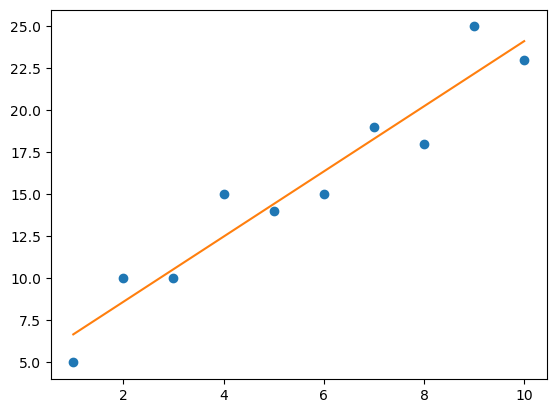

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Import points
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

# Extract input variables (all rows, all columns but last column)
X = df.values[:, :-1]

# Extract output column (all rows, last column)
Y = df.values[:, -1]

# Fit a line to the points
fit = LinearRegression().fit(X, Y)

# m = 1.7867224, b = -16.51923513
m = fit.coef_.flatten()
b = fit.intercept_.flatten()
print("m = {0}".format(m))
print("b = {0}".format(b))

# show in chart
plt.plot(X, Y, 'o') # scatterplot
plt.plot(X, m*X+b) # line
plt.show()

## Residuals and Squared Errors

How do statistics tools like scikit-learn come up with a line that fits to these points? It comes down to two questions:
1. What defines a "best fit"?
2. How do we get to that "best fit"?

We minimize the squares, or more specifically the sum of the squared residuals. The residual is the numeric difference between the line and the points. Points above the line will have a positive residual, and points below the line will have a negative residual. Another name for residuals are errors.

In [2]:
import pandas as pd

# Import points
points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",").itertuples()

# Test with a given line
m = 1.93939
b = 4.73333

# Calculate the residuals
for p in points:
    y_actual = p.y
    y_predict = m*p.x + b
    residual = y_actual - y_predict
    print(residual)

-1.67272
1.3878900000000005
-0.5515000000000008
2.5091099999999997
-0.4302799999999998
-1.3696699999999993
0.6909400000000012
-2.2484499999999983
2.812160000000002
-1.1272299999999973


If we are fitting a straight line through our 10 data points, we likely want to minimize these residuals in total so there is the least gap possible between the line and points. The best approach is to take the sum of squares, which simply squares each residual, or multiplies each residual by itself, and sums them. We don't use absolute values because they are mathematically inconvenient (they don't work well with calculus derivatives).

In [3]:
import pandas as pd

# Import points
points = pd.read_csv("https://bit.ly/2KF29Bd").itertuples()

# Test with a given line
m = 1.93939
b = 4.73333

sum_of_squares = 0.0

# calculate sum of squares
for p in points:
    y_actual = p.y
    y_predict = m*p.x + b
    residual_squared = (y_predict - y_actual)**2
    sum_of_squares += residual_squared

print("sum of squares = {}".format(sum_of_squares))

sum of squares = 28.096969704500005
